# Fan-Beam CT Reconstruction

This notebook demonstrates CT image reconstruction from fan-beam sinogram data — the standard clinical CT acquisition geometry where X-rays diverge from a rotating point source.

## Forward Model

In fan-beam CT, the X-ray source rotates around the object, emitting divergent rays to a flat detector:

$$p(\beta, t) = \int f(s_x + \ell \cdot d_x,\; s_y + \ell \cdot d_y)\, d\ell$$

Key differences from parallel-beam CT:
- **Divergent rays** require magnification-dependent weighting
- **Distance weighting** $1/U^2$ in back-projection
- **Short-scan** ($\pi + 2\gamma_{\max}$) requires Parker weighting

## Methods
1. **Fan-beam FBP**: pre-weight → ramp filter → distance-weighted backprojection
2. **TV-PDHG**: iterative total variation regularized reconstruction

In [1]:
import os, sys, json
import numpy as np
import matplotlib.pyplot as plt

TASK_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, TASK_DIR)

%matplotlib inline

## 1. Load Data and Geometry

In [2]:
from src.preprocessing import load_sinogram_data, load_ground_truth, load_metadata, preprocess_sinogram

sino_full, sino_short, angles_full, angles_short, det_pos = load_sinogram_data(TASK_DIR)
phantom = load_ground_truth(TASK_DIR)
meta = load_metadata(TASK_DIR)

print(f"Image size: {meta['image_size']}x{meta['image_size']}")
print(f"Detector elements: {meta['n_det']}")
print(f"Source-isocenter: {meta['source_to_isocenter_pixels']} px")
print(f"Fan half-angle: {meta['fan_half_angle_deg']:.1f} deg")
print(f"Full-scan: {meta['n_angles_full']} angles (360 deg)")
print(f"Short-scan: {meta['n_angles_short']} angles ({meta['short_scan_range_deg']:.1f} deg)")

Image size: 128x128
Detector elements: 192
Source-isocenter: 256.0 px
Fan half-angle: 26.4 deg
Full-scan: 180 angles (360 deg)
Short-scan: 116 angles (232.9 deg)


## 2. Ground Truth and Sinograms

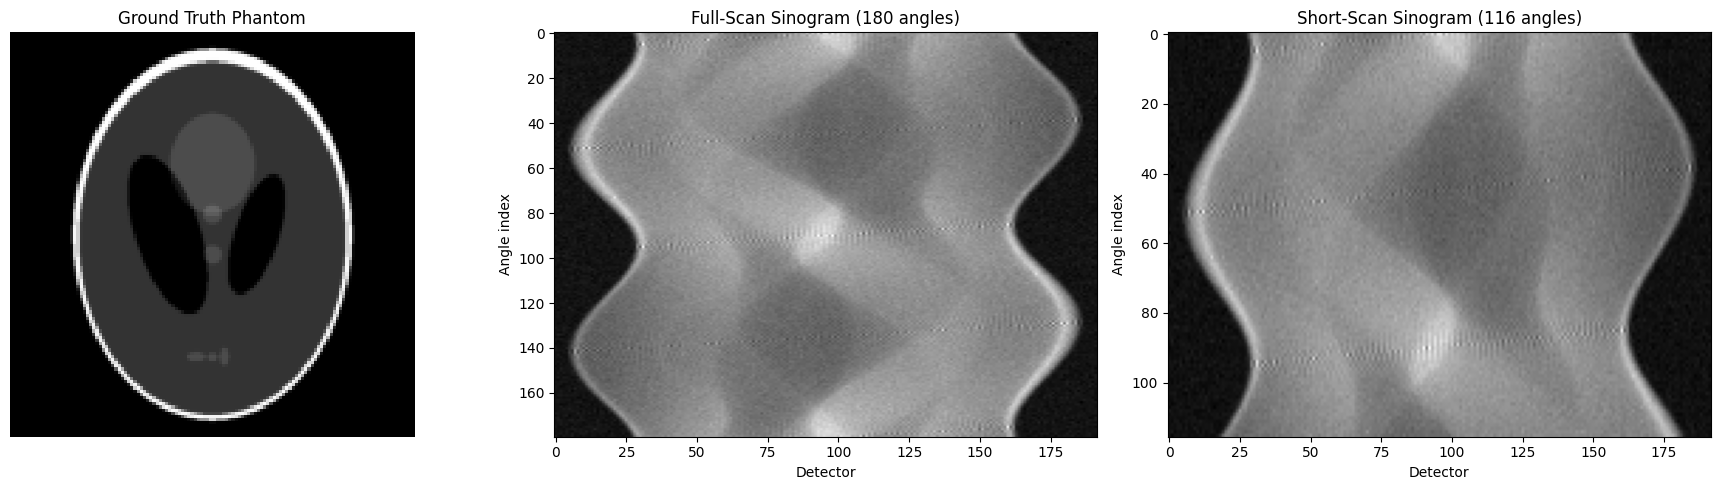

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(phantom[0], cmap='gray')
axes[0].set_title('Ground Truth Phantom')
axes[0].axis('off')

axes[1].imshow(sino_full[0], aspect='auto', cmap='gray')
axes[1].set_title(f'Full-Scan Sinogram ({meta["n_angles_full"]} angles)')
axes[1].set_xlabel('Detector')
axes[1].set_ylabel('Angle index')

axes[2].imshow(sino_short[0], aspect='auto', cmap='gray')
axes[2].set_title(f'Short-Scan Sinogram ({meta["n_angles_short"]} angles)')
axes[2].set_xlabel('Detector')
axes[2].set_ylabel('Angle index')

plt.tight_layout()
plt.show()

## 3. Fan-Beam Geometry Visualization

Visualize the fan-beam acquisition geometry: source positions, detector, and ray paths.

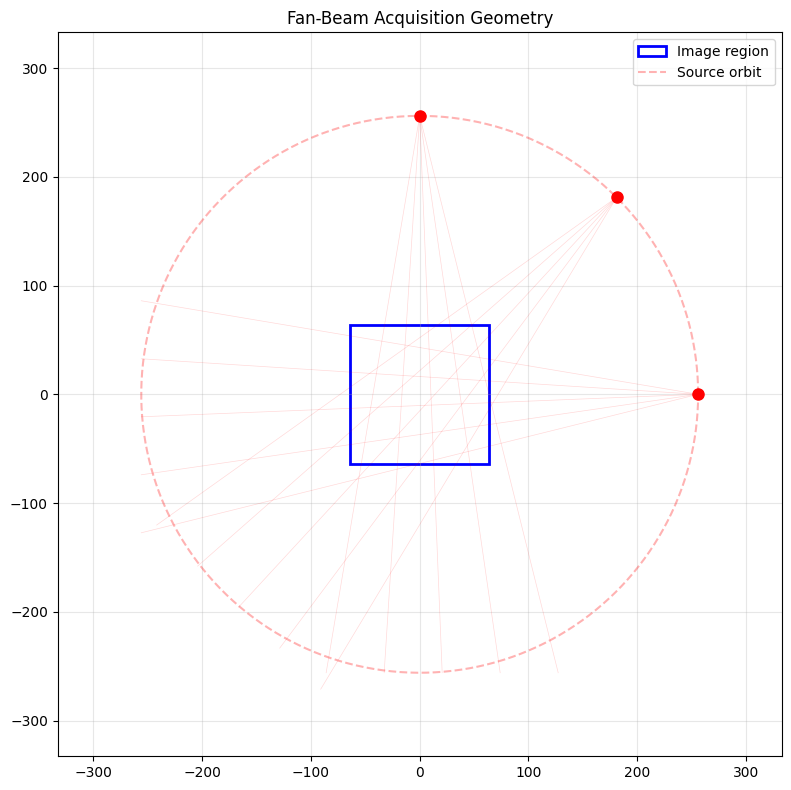

In [4]:
D_sd = meta['source_to_isocenter_pixels']
D_dd = meta['isocenter_to_detector_pixels']
N = meta['image_size']

fig, ax = plt.subplots(figsize=(8, 8))

# Draw image region
rect = plt.Rectangle((-N/2, -N/2), N, N, fill=False, edgecolor='blue', lw=2, label='Image region')
ax.add_patch(rect)

# Draw source trajectory
theta_circle = np.linspace(0, 2*np.pi, 200)
ax.plot(D_sd*np.cos(theta_circle), D_sd*np.sin(theta_circle), 'r--', alpha=0.3, label='Source orbit')

# Show a few source-detector ray bundles
for angle in [0, np.pi/4, np.pi/2]:
    sx = D_sd * np.cos(angle)
    sy = D_sd * np.sin(angle)
    ax.plot(sx, sy, 'ro', markersize=8)
    for t in det_pos[::40]:
        dx = -D_dd * np.cos(angle) - t * np.sin(angle)
        dy = -D_dd * np.sin(angle) + t * np.cos(angle)
        ax.plot([sx, dx], [sy, dy], 'r-', alpha=0.15, lw=0.5)

ax.set_xlim(-D_sd*1.3, D_sd*1.3)
ax.set_ylim(-D_sd*1.3, D_sd*1.3)
ax.set_aspect('equal')
ax.legend()
ax.set_title('Fan-Beam Acquisition Geometry')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Precomputed Reconstructions

Load precomputed results from `evaluation/reference_outputs/`.

In [5]:
ref_dir = os.path.join(TASK_DIR, 'evaluation', 'reference_outputs')

fbp_full = np.load(os.path.join(ref_dir, 'recon_fbp_full.npz'))['reconstruction'][0]
fbp_short = np.load(os.path.join(ref_dir, 'recon_fbp_short.npz'))['reconstruction'][0]
tv_data = np.load(os.path.join(ref_dir, 'recon_tv_short.npz'))
tv_short = tv_data['reconstruction'][0]
loss_history = tv_data['loss_history']

gt = phantom[0]
vmin, vmax = gt.min(), gt.max()

## 5. Full-Scan vs Short-Scan FBP

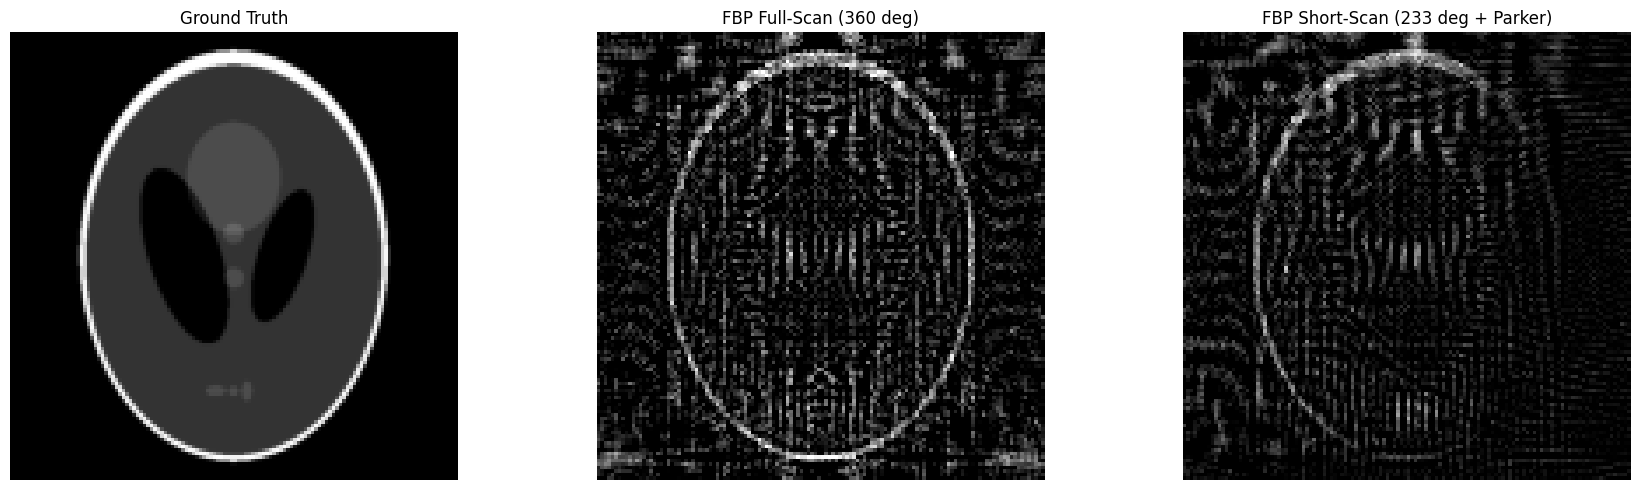

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(gt, cmap='gray', vmin=vmin, vmax=vmax)
axes[0].set_title('Ground Truth')
axes[0].axis('off')

axes[1].imshow(fbp_full, cmap='gray', vmin=vmin, vmax=vmax)
axes[1].set_title('FBP Full-Scan (360 deg)')
axes[1].axis('off')

axes[2].imshow(fbp_short, cmap='gray', vmin=vmin, vmax=vmax)
axes[2].set_title(f'FBP Short-Scan ({meta["short_scan_range_deg"]:.0f} deg + Parker)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 6. TV-PDHG Iterative Reconstruction (Short-Scan)

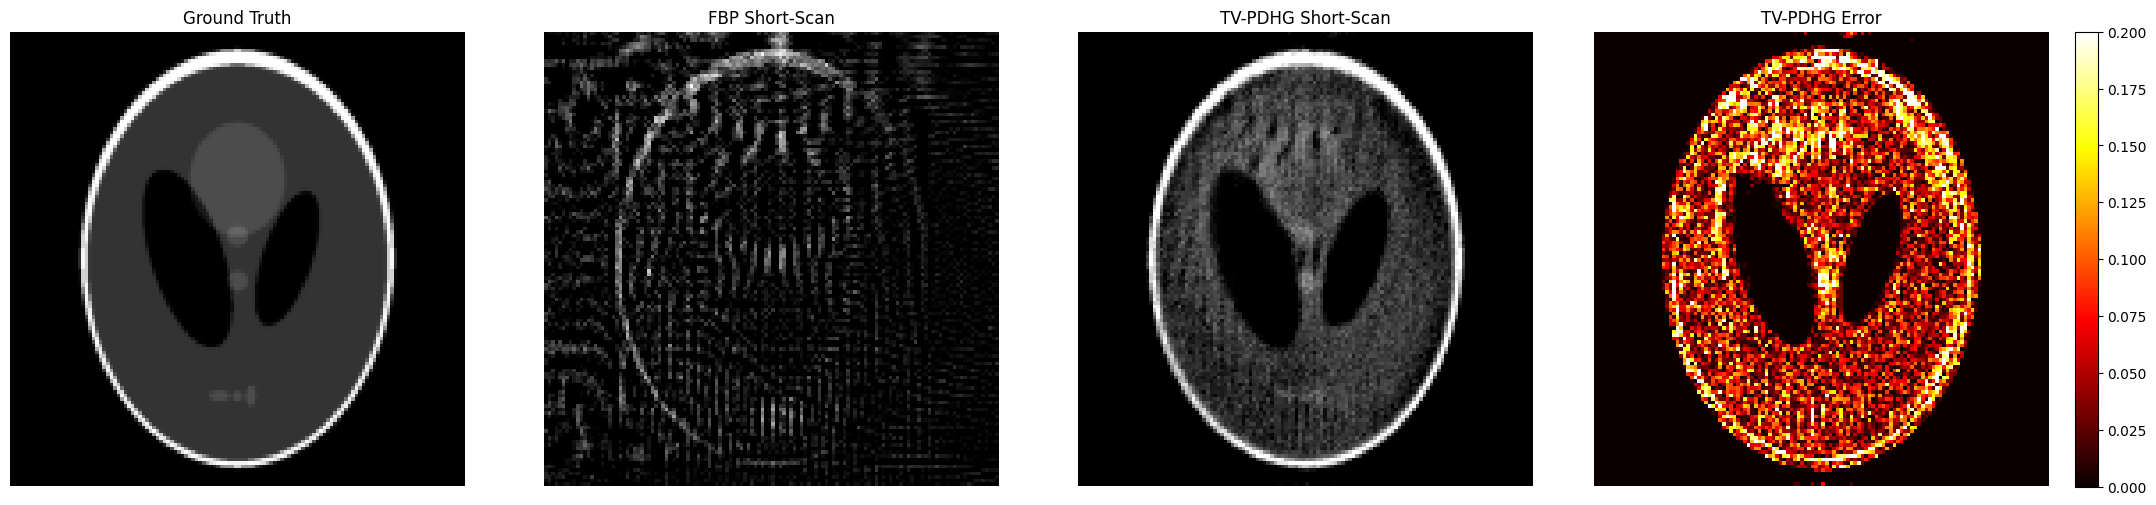

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

axes[0].imshow(gt, cmap='gray', vmin=vmin, vmax=vmax)
axes[0].set_title('Ground Truth')
axes[0].axis('off')

axes[1].imshow(fbp_short, cmap='gray', vmin=vmin, vmax=vmax)
axes[1].set_title('FBP Short-Scan')
axes[1].axis('off')

axes[2].imshow(tv_short, cmap='gray', vmin=vmin, vmax=vmax)
axes[2].set_title('TV-PDHG Short-Scan')
axes[2].axis('off')

error = np.abs(tv_short - gt)
im = axes[3].imshow(error, cmap='hot', vmin=0, vmax=vmax*0.2)
axes[3].set_title('TV-PDHG Error')
axes[3].axis('off')
plt.colorbar(im, ax=axes[3], fraction=0.046)

plt.tight_layout()
plt.show()

## 7. Convergence Plot

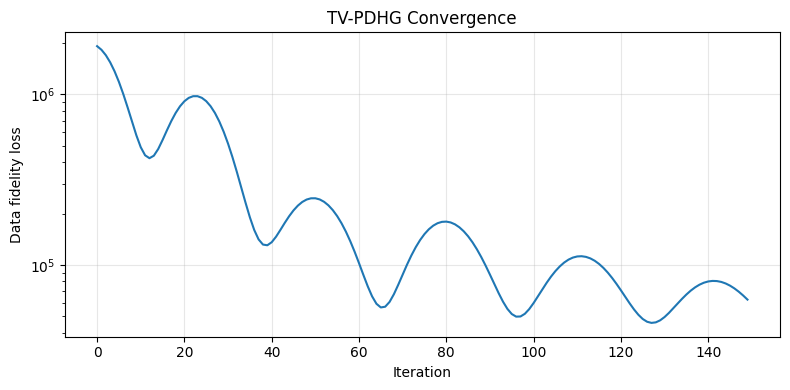

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(loss_history)
ax.set_xlabel('Iteration')
ax.set_ylabel('Data fidelity loss')
ax.set_title('TV-PDHG Convergence')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Quantitative Metrics

In [9]:
with open(os.path.join(TASK_DIR, 'evaluation', 'metrics.json')) as f:
    metrics = json.load(f)

print("Method                               | NCC    | NRMSE")
print("-" * 55)
for entry in metrics['baseline']:
    print(f"{entry['method']:36s} | {entry['ncc_vs_ref']:.4f} | {entry['nrmse_vs_ref']:.4f}")
print(f"\nBoundaries: NCC >= {metrics['ncc_boundary']:.4f}, NRMSE <= {metrics['nrmse_boundary']:.4f}")

Method                               | NCC    | NRMSE
-------------------------------------------------------
FBP full-scan (360 deg)              | 0.6518 | 0.1929
FBP short-scan with Parker weighting | 0.5578 | 0.2110
TV-PDHG short-scan                   | 0.9661 | 0.0855

Boundaries: NCC >= 0.8695, NRMSE <= 0.0941


## 9. Optional: Run Full Pipeline from Scratch

Uncomment to reproduce (takes ~2 minutes).

In [10]:
# from src.physics_model import fan_beam_geometry, fan_beam_fbp
# from src.solvers import solve_tv_pdhg
# from src.visualization import compute_ncc, compute_nrmse, centre_crop_normalize
#
# sino_full_2d = preprocess_sinogram(sino_full)
# sino_short_2d = preprocess_sinogram(sino_short)
# short_range = meta['short_scan_range_deg'] * np.pi / 180
# geo_short = fan_beam_geometry(N, meta['n_det'], len(angles_short),
#                               D_sd, D_dd, angle_range=short_range)
#
# recon_fbp = fan_beam_fbp(sino_short_2d, geo_short, short_scan=True)
# recon_tv, loss = solve_tv_pdhg(sino_short_2d, geo_short, lam=0.005, n_iter=150)
#
# gt_c = centre_crop_normalize(gt)
# tv_c = centre_crop_normalize(recon_tv)
# print(f"TV NCC: {compute_ncc(tv_c, gt_c):.4f}")

## Conclusion

**Key observations:**

1. **Fan-beam FBP** provides a fast analytical reconstruction, but image quality depends heavily on the pre-weighting and filtering. The pixel-driven forward model introduces some approximation that FBP is sensitive to.

2. **Short-scan FBP** with Parker weighting works with ~2/3 the angular data of a full scan, but shows more artifacts due to reduced angular sampling and the smooth weighting transition.

3. **TV-PDHG** dramatically improves reconstruction quality (NCC > 0.96) by exploiting the piecewise-constant nature of the phantom through total variation regularization.

4. **Fan-beam vs parallel-beam**: the divergent geometry requires distance-dependent weighting in both the forward model and reconstruction. The magnification effect means detector sampling is non-uniform across the field of view.

**Challenges for real data:**
- Beam hardening effects (polychromatic X-rays)
- Scatter correction
- Metal artifacts
- Helical (spiral) acquisition in modern multi-slice CT